### Setup

In [ ]:
#!pip install statsmodels
#!pip install tensorflow
#!pip install torch torchvision

In [1]:
# Import libraries 
# data manipulation
import pandas as pd
import statsmodels.api as sm

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Neural Networks
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from transformers import BertTokenizer, BertForSequenceClassification
from transformers import RobertaTokenizer, RobertaForSequenceClassification

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set a fixed seed value for reproducibility
seed = 6

# Target & text variable names
target_variable = 'onrust'
text_variable = 'rapportage'

### Data preparation

In [2]:
# Load training and validation data
df_train = pd.read_csv('../zorgdata/df_train.csv', index_col=False)
df_valid = pd.read_csv('../zorgdata/df_valid.csv', index_col=False)

In [3]:
# Selecti variables for the models. Excluded variables are not used in model training
excluded = ['ct_id', 'datum', 'rapportage', 'onrustscore', 'rapportage_clean', 
            'rapportage_len_chars', 'rapportage_clean_len_chars', 'rapportage_clean_len_words', 'discipline']

label = target_variable # Target variable

# Prepare training and validation sets by dropping excluded variables
X_train = df_train.drop(excluded + [label], axis=1)
y_train = df_train[label]

X_valid = df_valid.drop(excluded + [label], axis=1)
y_valid = df_valid[label]

# Add constant term for logistic regression
X_train_c = X_train.assign(const=1)

### Logistisc regression

In [4]:
# Train the logistic regression model
lr_model = sm.Logit(y_train, X_train_c)
result = lr_model.fit()

# Calculate initial AIC for model comparison
initial_aic = result.aic

# Perform backward elimination based on p-values and AIC
while True:
    max_p_value = result.pvalues.max()

    if max_p_value > 0.05:
        variable_to_remove = result.pvalues.idxmax()
        X_train_c = X_train_c.drop(variable_to_remove, axis=1)
        
        # Gebruik sm.Logit consistent
        lr_model = sm.Logit(y_train, X_train_c)
        result = lr_model.fit()
        
        # Bereken de nieuwe AIC
        new_aic = result.aic
        
        # Stop als de AIC niet meer verbetert
        if new_aic >= initial_aic:
            break
        else:
            initial_aic = new_aic
    else:
        # Als alle p-waarden onder de drempelwaarde liggen, stop dan de eliminatie
        break

# Bekijk de uiteindelijke samenvatting van het model
print(result.summary2())

         Current function value: 0.241033
         Iterations: 35


/Users/eva/anaconda3/envs/nlp_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Optimization terminated successfully.
         Current function value: 0.241033
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.241033
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.241034
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.241037
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.241040
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.241047
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.241082
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.241102
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.241131
         Iterations 9
Optimization terminated successfully.
         Current function value: 0.241176
  

In [5]:
# Prepare validation data with selected variables
selected_variables = X_train_c.columns.tolist()
X_valid_c = df_valid.assign(const=1)[selected_variables]

In [6]:
# Make predictions on validation set and adding them to a new dataframe

# Create new df with predictions
df_valid_pred = df_valid[['ct_id', 'datum', 'onrustscore', target_variable, 'rapportage']].copy()

# Add predicted probability and predicted label
df_valid_pred['pred_lr_prob'] = result.predict(X_valid_c)
df_valid_pred['pred_lr'] = (df_valid_pred['pred_lr_prob'] >= 0.5).astype(int)

### Random forest

In [7]:
# # Uncomment below to perform hyperparameter tuning using GridSearchCV
# param_grid = {
#     'n_estimators': [100, 501],
#     'max_depth': [None, 10, 30],
#     'min_samples_split': [2, 10],
#     'min_samples_leaf': [1, 4]
# }

# # Initialize Grid Search with cross-validation
# grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=seed), 
#                            param_grid=param_grid, 
#                            cv=5, # Aantal folds voor crossvalidaion
#                            n_jobs=-1, # Gebruik alle beschikbare CPU-cores
#                            verbose=2, # Toon gedetailleerde voortgangsinformatie
#                            scoring='roc_auc') # AUC als prestatie-indicator

# # Perform Grid Search with training data
# grid_search.fit(X_train, y_train)

# # Best parameters and AUC-score
# print("Beste hyperparameters:", grid_search.best_params_)
# print("Beste AUC-score:", grid_search.best_score_)

# # Best model
# best_rf_model = grid_search.best_estimator_

In [8]:
# Train the Random Forest model with specified parameters
rf_model = RandomForestClassifier(n_estimators=501, 
                                  random_state=seed, 
                                  max_depth=None, 
                                  min_samples_leaf=4, 
                                  min_samples_split=2)
rf_model.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=4, n_estimators=501, random_state=6)

In [9]:
# Make predictions on validation set
df_valid_pred['pred_rf'] = rf_model.predict(X_valid)
df_valid_pred['pred_rf_prob'] = rf_model.predict_proba(X_valid)[:, 1]

In [10]:
# Display feature importances
feature_importances = pd.DataFrame(rf_model.feature_importances_,
                                   index = X_train.columns,
                                   columns=['importance']).sort_values('importance', ascending=False)
print(feature_importances[0:10])

              importance
topic_2         0.114875
embedding_4     0.086122
embedding_38    0.064477
embedding_15    0.062182
embedding_13    0.044758
embedding_42    0.038749
embedding_43    0.037445
embedding_18    0.036688
embedding_0     0.034463
embedding_34    0.030938


### TensorFlow Neural Network

In [11]:
# Normalize the features for TensorFlow model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

In [12]:
# Construct the TensorFlow neural network
tf_model = Sequential()
tf_model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
tf_model.add(Dense(32, activation='relu'))
tf_model.add(Dense(1, activation='sigmoid')) # Uitvoerlaag voor binaire classificatie

In [13]:
# Compile the TensorFlow model
tf_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [14]:
# Train the TensorFlow model
history = tf_model.fit(X_train_scaled, y_train, epochs=10, batch_size=32, validation_data=(X_valid_scaled, y_valid))

Epoch 1/10
181/181 [==============================] - 0s 987us/step - loss: 0.3264 - accuracy: 0.8514 - val_loss: 0.2615 - val_accuracy: 0.8879
Epoch 2/10
181/181 [==============================] - 0s 608us/step - loss: 0.2778 - accuracy: 0.8731 - val_loss: 0.2563 - val_accuracy: 0.8886
Epoch 3/10
181/181 [==============================] - 0s 608us/step - loss: 0.2693 - accuracy: 0.8772 - val_loss: 0.2527 - val_accuracy: 0.8906
Epoch 4/10
181/181 [==============================] - 0s 608us/step - loss: 0.2627 - accuracy: 0.8798 - val_loss: 0.2471 - val_accuracy: 0.8941
Epoch 5/10
181/181 [==============================] - 0s 594us/step - loss: 0.2584 - accuracy: 0.8835 - val_loss: 0.2525 - val_accuracy: 0.8851
Epoch 6/10
181/181 [==============================] - 0s 586us/step - loss: 0.2559 - accuracy: 0.8816 - val_loss: 0.2441 - val_accuracy: 0.8893
Epoch 7/10
181/181 [==============================] - 0s 580us/step - loss: 0.2501 - accuracy: 0.8876 - val_loss: 0.2442 - val_accuracy:

In [15]:
# Evaluate the TensorFlow model
loss, accuracy = tf_model.evaluate(X_valid_scaled, y_valid)
print(f'Validatie nauwkeurigheid: {accuracy:.2f}, Verlies: {loss:.2f}')

46/46 [==============================] - 0s 399us/step - loss: 0.2378 - accuracy: 0.8968
Validatie nauwkeurigheid: 0.90, Verlies: 0.24


In [16]:
# Predict probabilities for the validation set using TensorFlow model
df_valid_pred['pred_tf_prob'] = tf_model.predict(X_valid_scaled)
df_valid_pred['pred_tf'] = (df_valid_pred['pred_tf_prob'] > 0.5).astype("int32")

46/46 [==============================] - 0s 316us/step


### PyTorch Neural Network

In [25]:
# Prepare the data for PyTorch model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
X_valid_tensor = torch.tensor(X_valid_scaled, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid.values, dtype=torch.float32)

# Create datasets and DataLoaders for PyTorch
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

In [26]:
# Define the PyTorch neural network
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(X_train_scaled.shape[1], 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

# Initialize model, loss function, and optimizer for PyTorch
pt_model = NeuralNet()
criterion = nn.BCELoss()
optimizer = optim.Adam(pt_model.parameters(), lr=0.001)

In [27]:
# Train the PyTorch model
num_epochs = 10
for epoch in range(num_epochs):
    pt_model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = pt_model(X_batch)
        loss = criterion(y_pred.squeeze(), y_batch)
        loss.backward()
        optimizer.step()

    # Validate the PyTorch model
    pt_model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for X_batch, y_batch in valid_loader:
            y_pred = pt_model(X_batch)
            predicted = (y_pred.squeeze() > 0.5).float()
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    accuracy = 100 * correct / total
    print(f'Epoch {epoch+1}, Verlies: {loss.item():.4f}, Nauwkeurigheid: {accuracy:.2f}%')

Epoch 1, Verlies: 0.2810, Nauwkeurigheid: 88.93%
Epoch 2, Verlies: 0.2031, Nauwkeurigheid: 89.55%
Epoch 3, Verlies: 0.2451, Nauwkeurigheid: 88.79%
Epoch 4, Verlies: 0.1571, Nauwkeurigheid: 89.00%
Epoch 5, Verlies: 0.4125, Nauwkeurigheid: 89.06%
Epoch 6, Verlies: 0.4616, Nauwkeurigheid: 89.13%
Epoch 7, Verlies: 0.3174, Nauwkeurigheid: 89.55%
Epoch 8, Verlies: 0.2467, Nauwkeurigheid: 89.06%
Epoch 9, Verlies: 0.5082, Nauwkeurigheid: 89.00%
Epoch 10, Verlies: 0.1838, Nauwkeurigheid: 89.13%


In [28]:
# Calculate predicted probabilities and labels using PyTorch model
pt_model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    df_valid_pred['pred_pt_prob'] = pt_model(X_valid_tensor).numpy().ravel()

# Convert the predicted probabilities to labels
df_valid_pred['pred_pt'] = (df_valid_pred['pred_pt_prob'] >= 0.5)

### Bert

In [17]:
# Path where the model is saved
model_path = '../models/bert_classification' 

# Load the finetuned Bert model
bc_model = BertForSequenceClassification.from_pretrained(model_path)
bc_tokenizer = BertTokenizer.from_pretrained('wietsedv/bert-base-dutch-cased')

In [18]:
# Get validation encodings for the Bert model
validation_encodings = bc_tokenizer(df_valid_pred[text_variable].tolist(), truncation=True, padding=True, max_length=512, return_tensors="pt")

In [19]:
# Predict probabilities with the Bert model
bc_model.eval()  
with torch.no_grad():
    logits = bc_model(**validation_encodings).logits
    probabilities = torch.nn.functional.softmax(logits, dim=1)
    df_valid_pred['pred_bert_prob'] = probabilities[:, 1].numpy()  # Probability of class '1'

# Convert the probabilities to labels
df_valid_pred['pred_bert'] = (df_valid_pred['pred_bert_prob'] >= 0.5)

### Roberta

In [20]:
# Path where the model is saved
model_path = '../models/RobertaClassification' 

# Load the finetuned RoBerta model
rb_model = RobertaForSequenceClassification.from_pretrained(model_path)
rb_tokenizer = RobertaTokenizer.from_pretrained('pdelobelle/robbert-v2-dutch-base')

In [21]:
# Get validation encodings for the Roberta model
validation_encodings = rb_tokenizer(df_valid_pred[text_variable].tolist(), truncation=True, padding=True, max_length=512, return_tensors="pt")

In [22]:
# Predict probabilities with the Roberta model
rb_model.eval()  
with torch.no_grad():
    logits = rb_model(**validation_encodings).logits
    probabilities = torch.nn.functional.softmax(logits, dim=1)
    df_valid_pred['pred_roberta_prob'] = probabilities[:, 1].numpy()  # Probability of class '1'

# Convert the probabilities to labels
df_valid_pred['pred_roberta'] = (df_valid_pred['pred_roberta_prob'] >= 0.5)

### Evaluate

In [24]:
df_valid_pred.head()

,ct_id,datum,onrustscore,onrust,rapportage,pred_lr_prob,pred_lr,pred_rf,pred_rf_prob,pred_tf_prob,pred_tf,pred_bert_prob,pred_bert,pred_roberta_prob,pred_roberta
0,kamer03,2024-01-01,32.0,False,Meneer Jansen had vandaag een rustige dag. Hij...,0.001666,0,False,0.000000,0.000002,0,0.000283,False,0.000353,False
1,kamer03,2024-01-02,45.0,False,Meneer Jansen was vandaag wat onrustig tijdens...,0.031399,0,False,0.003599,0.011192,0,0.018368,False,0.017884,False
2,kamer03,2024-01-03,18.0,False,Meneer Jansen had vandaag een rustige dag met ...,0.014144,0,False,0.000000,0.000124,0,0.000291,False,0.000353,False
3,kamer03,2024-01-04,50.0,False,Meneer Jansen was vandaag verward en onrustig....,0.671174,1,True,0.573552,0.758181,1,0.639349,True,0.690101,True
4,kamer03,2024-01-05,14.0,False,Meneer Jansen was vandaag rustig en alert. Hij...,0.001557,0,False,0.000000,0.000007,0,0.000256,False,0.000341,False


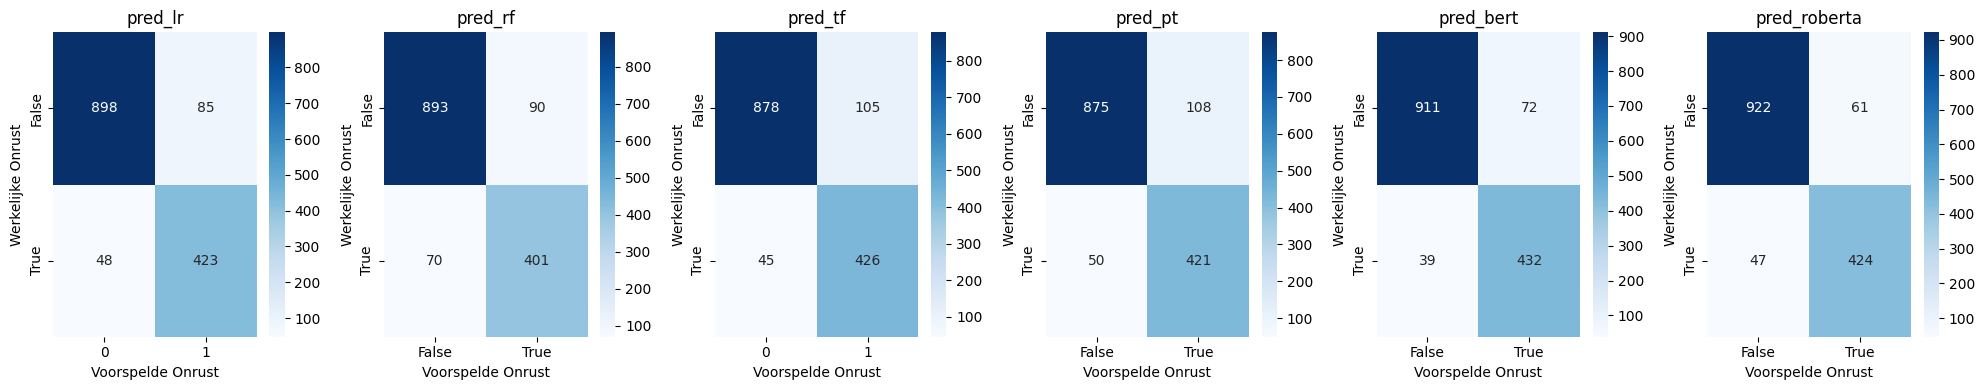

In [29]:
def plot_contingency(data, model_name, subplot):
    # Create a cross-tabulation heatmap for given model predictions vs actual values
    kruistabel = pd.crosstab(data[target_variable], data[model_name], 
                             rownames=['Werkelijke Onrust'], colnames=['Voorspelde Onrust'])
    sns.heatmap(kruistabel, annot=True, fmt='d', cmap='Blues', ax=subplot)
    subplot.set_title(model_name)

# Prepare figure and define subplots for visual comparison
fig, axs = plt.subplots(1, 6, figsize=(20, 4))  # 5 compare side-by-side

# Plot each model's cross-tabulation in its own subplot
plot_contingency(df_valid_pred, 'pred_lr', axs[0])
plot_contingency(df_valid_pred, 'pred_rf', axs[1])
plot_contingency(df_valid_pred, 'pred_tf', axs[2])
plot_contingency(df_valid_pred, 'pred_pt', axs[3])
plot_contingency(df_valid_pred, 'pred_bert', axs[4])
plot_contingency(df_valid_pred, 'pred_roberta', axs[5])

plt.tight_layout()
plt.show()

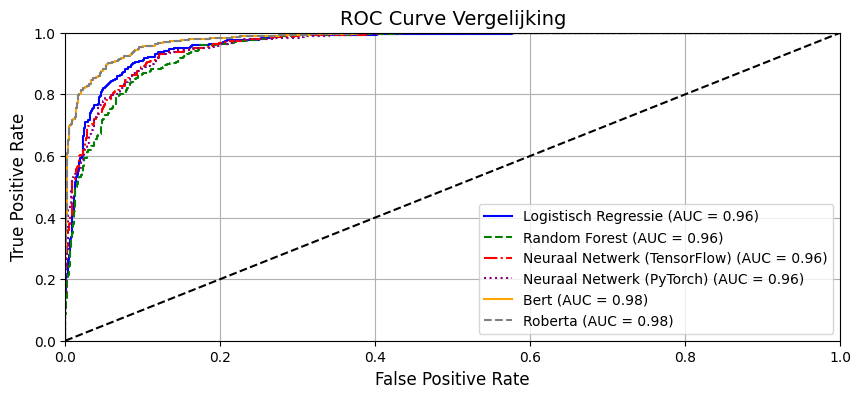

In [30]:
# Calculate ROC curves for each model
fpr_lr, tpr_lr, thresholds_lr = roc_curve(df_valid_pred[target_variable], df_valid_pred['pred_lr_prob'])
fpr_rf, tpr_rf, thresholds_rf = roc_curve(df_valid_pred[target_variable], df_valid_pred['pred_rf_prob'])
fpr_tf, tpr_tf, thresholds_tf = roc_curve(df_valid_pred[target_variable], df_valid_pred['pred_tf_prob'])
fpr_pt, tpr_pt, thresholds_pt = roc_curve(df_valid_pred[target_variable], df_valid_pred['pred_pt_prob'])
fpr_bert, tpr_bert, thresholds_bert = roc_curve(df_valid_pred[target_variable], df_valid_pred['pred_bert_prob'])
fpr_roberta, tpr_roberta, thresholds_roberta = roc_curve(df_valid_pred[target_variable], df_valid_pred['pred_roberta_prob'])

# Calculate Area Under Curve (AUC) for each model
roc_auc_lr = roc_auc_score(df_valid_pred[target_variable], df_valid_pred['pred_lr_prob'])
roc_auc_rf = roc_auc_score(df_valid_pred[target_variable], df_valid_pred['pred_rf_prob'])
roc_auc_tf = roc_auc_score(df_valid_pred[target_variable], df_valid_pred['pred_tf_prob'])
roc_auc_pt = roc_auc_score(df_valid_pred[target_variable], df_valid_pred['pred_pt_prob'])
roc_auc_bert = roc_auc_score(df_valid_pred[target_variable], df_valid_pred['pred_bert_prob'])
roc_auc_roberta = roc_auc_score(df_valid_pred[target_variable], df_valid_pred['pred_roberta_prob'])

plt.figure(figsize=(10, 4))

# Plot the ROC Curves for each model
plt.plot(fpr_lr, tpr_lr, label='Logistisch Regressie (AUC = {:.2f})'.format(roc_auc_lr), color='blue', linestyle='-')
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = {:.2f})'.format(roc_auc_rf), color='green', linestyle='--')
plt.plot(fpr_tf, tpr_tf, label='Neuraal Netwerk (TensorFlow) (AUC = {:.2f})'.format(roc_auc_tf), color='red', linestyle='-.')
plt.plot(fpr_pt, tpr_pt, label='Neuraal Netwerk (PyTorch) (AUC = {:.2f})'.format(roc_auc_pt), color='purple', linestyle=':')
plt.plot(fpr_bert, tpr_bert, label='Bert (AUC = {:.2f})'.format(roc_auc_bert), color='orange', linestyle='-')
plt.plot(fpr_bert, tpr_bert, label='Roberta (AUC = {:.2f})'.format(roc_auc_roberta), color='grey', linestyle='--')

# Baseline for comparison
plt.plot([0, 1], [0, 1], 'k--')

# Axes and title
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Vergelijking', fontsize=14)

# Legend
plt.legend(loc='lower right', fontsize=10)

# Grid for readability
plt.grid(True)

# Set axis limits
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

plt.show()

In [31]:
# Predict on custom text
custom_text = "Hij heeft me geslagen"

# Tokenize the text for Bert model
inputs = bc_tokenizer(custom_text, padding=True, truncation=True, max_length=512, return_tensors="pt")

# Predict using the Bert model
bc_model.eval()
with torch.no_grad():
    outputs = bc_model(**inputs)
    logits = outputs.logits

# Convert logits to probabilities
probabilities = torch.nn.functional.softmax(logits, dim=1)

# Extract the highest probability and its corresponding label
predicted_prob, predicted_label = torch.max(probabilities, dim=1)
predicted_prob = predicted_prob.item() # Convert to a Python number
predicted_label = predicted_label.item() # Convert to a Python number

print(f"Predicted Label: {predicted_label}, Predicted Probability: {predicted_prob:.2f}")


Predicted Label: 1, Predicted Probability: 0.87


In [32]:
def evaluate_model_performance(actuals, predictions, model_name="Model"):
    """
    Evaluates the performance of a binary classification model including specificity and NPV.

    Parameters:
    actuals (array-like): The actual labels.
    predictions (array-like): The predicted labels.
    model_name (str): Name of the model for display purposes.

    Returns:
    None: Prints the performance metrics.
    """
    # Calculate the confusion matrix
    tn, fp, fn, tp = confusion_matrix(actuals, predictions).ravel()

    # Calculate the metrics
    accuracy = accuracy_score(actuals, predictions)
    precision = precision_score(actuals, predictions)  # Positive Predictive Value (PPV)
    recall = recall_score(actuals, predictions)  # Sensitivity or True Positive Rate
    f1 = f1_score(actuals, predictions)
    specificity = tn / (tn + fp)
    npv = tn / (tn + fn)  # Negative Predictive Value (NPV)

    model_name = model_name.ljust(20)

    # Print the results
    print(f"{model_name} - Accuracy: {accuracy:.2f}, Precision (PPV): {precision:.2f}, NPV: {npv:.2f}, Recall (Sensitivity): {recall:.2f}, Specificity: {specificity:.2f}, F1 Score: {f1:.2f}")


In [33]:
evaluate_model_performance(df_valid_pred[target_variable], df_valid_pred['pred_lr'], 'Logistic regression')
evaluate_model_performance(df_valid_pred[target_variable], df_valid_pred['pred_rf'], 'Random Forest')
evaluate_model_performance(df_valid_pred[target_variable], df_valid_pred['pred_tf'], 'TensorFlow')
evaluate_model_performance(df_valid_pred[target_variable], df_valid_pred['pred_pt'], 'PyTorch')
evaluate_model_performance(df_valid_pred[target_variable], df_valid_pred['pred_bert'], 'Bert llm')
evaluate_model_performance(df_valid_pred[target_variable], df_valid_pred['pred_roberta'], 'Roberta llm')

Logistic regression  - Accuracy: 0.91, Precision (PPV): 0.83, NPV: 0.95, Recall (Sensitivity): 0.90, Specificity: 0.91, F1 Score: 0.86
Random Forest        - Accuracy: 0.89, Precision (PPV): 0.82, NPV: 0.93, Recall (Sensitivity): 0.85, Specificity: 0.91, F1 Score: 0.83
TensorFlow           - Accuracy: 0.90, Precision (PPV): 0.80, NPV: 0.95, Recall (Sensitivity): 0.90, Specificity: 0.89, F1 Score: 0.85
PyTorch              - Accuracy: 0.89, Precision (PPV): 0.80, NPV: 0.95, Recall (Sensitivity): 0.89, Specificity: 0.89, F1 Score: 0.84
Bert llm             - Accuracy: 0.92, Precision (PPV): 0.86, NPV: 0.96, Recall (Sensitivity): 0.92, Specificity: 0.93, F1 Score: 0.89
Roberta llm          - Accuracy: 0.93, Precision (PPV): 0.87, NPV: 0.95, Recall (Sensitivity): 0.90, Specificity: 0.94, F1 Score: 0.89


In [ ]:
df_valid_pred.to_csv('../zorgdata/df_valid_pred.csv')